# Taller Práctico Clase 1: Introducción a Machine Learning

**Objetivo:** En este notebook, aplicaremos los conceptos fundamentales vistos en clase. Nos familiarizaremos con las herramientas básicas y realizaremos el paso más importante antes de entrenar cualquier modelo: la preparación y división de nuestros datos.

**Pasos a seguir:**
1.  **Importar librerías:** Cargar las herramientas que necesitaremos.
2.  **Cargar el dataset:** Usaremos el famoso dataset "Iris".
3.  **Exploración de Datos (EDA):** Entenderemos la estructura y contenido de nuestros datos.
4.  **Visualización simple:** Crearemos gráficos para observar las relaciones entre variables.
5.  **División Train-Test:** Separaremos nuestros datos en conjuntos de entrenamiento y prueba.

---

### 1. Importar Librerías

Primero, importamos las librerías que usaremos. Es una buena práctica hacerlo al inicio del notebook.
- **pandas:** Para manipulación de datos en formato de tabla (DataFrame).
- **scikit-learn:** La librería de Machine Learning por excelencia en Python. La usaremos para cargar el dataset y para dividir los datos.
- **matplotlib:** Para crear visualizaciones.

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

print("Librerías importadas correctamente!")

Librerías importadas correctamente!


---

### 2. Cargar el Dataset

Vamos a cargar el dataset **Iris**, que viene incluido en `scikit-learn`. Este dataset contiene mediciones de 3 especies diferentes de flores de Iris.

El objeto que carga `scikit-learn` tiene varias partes útiles:
- `data`: Contiene las características (features) de las flores (largo y ancho de sépalo y pétalo).
- `target`: Contiene la etiqueta o especie de cada flor (la variable que queremos predecir).
- `feature_names`: Los nombres de las columnas en `data`.
- `target_names`: Los nombres de las especies en `target`.

In [30]:
# Cargamos el dataset
iris_raw = load_iris()

# Convertimos los datos a un DataFrame de pandas para facilitar su manipulación
# Las columnas serán los nombres de las características
iris_df = pd.DataFrame(data=iris_raw.data, columns=iris_raw.feature_names)

# Añadimos la columna 'species' (nuestro objetivo o target)
iris_df['species'] = iris_raw.target

# Mapeamos los números del target a los nombres de las especies para mayor claridad
species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
iris_df['species_name'] = iris_df['species'].map(species_map)

---

### 3. Exploración de Datos (EDA)

Antes de hacer cualquier modelo, debemos entender nuestros datos. ¿Cómo se ven? ¿Cuántos datos tenemos? ¿Hay valores faltantes?

In [31]:
# Visualizamos las primeras 5 filas del DataFrame
print("Primeras 5 filas del dataset:")
iris_df.head()

Primeras 5 filas del dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [32]:
# Obtenemos información general del DataFrame
# Nos muestra el tipo de datos por columna y si hay valores nulos.
print("Información general del dataset:")
iris_df.info()

Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [33]:
# Obtenemos un resumen estadístico de las columnas numéricas
print("Resumen estadístico:")
iris_df.describe()

Resumen estadístico:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [34]:
# Contamos cuántas muestras tenemos de cada especie
# Esto es importante para saber si el dataset está balanceado
print("Distribución de especies:")
iris_df['species_name'].value_counts()

Distribución de especies:


species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

> **Observación:** El dataset está perfectamente balanceado, con 50 muestras de cada especie. Esto es ideal, pero no es común en problemas del mundo real.

---

### 4. Visualización Simple

Usemos `matplotlib` para visualizar la relación entre dos de las características más informativas: el largo y el ancho del pétalo. Colorearemos cada punto según su especie para ver si son visualmente separables.

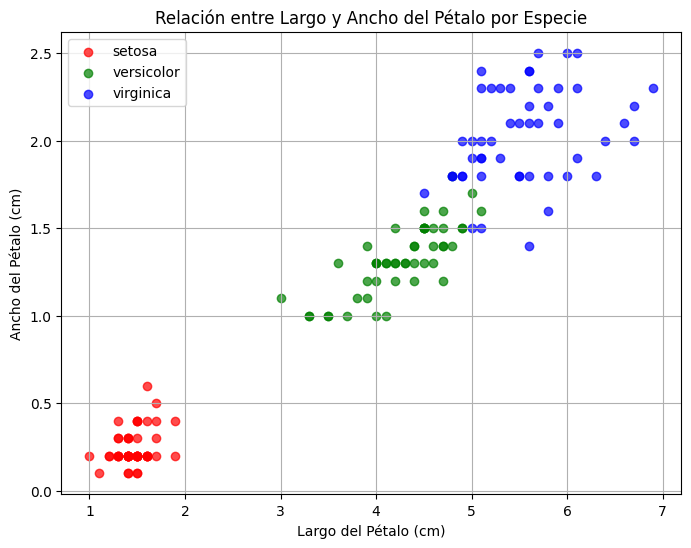

In [35]:
# Preparamos la figura y los ejes para el gráfico
fig, ax = plt.subplots(figsize=(8, 6))

# Definimos colores para cada especie
colors = {'setosa': 'red', 'versicolor': 'green', 'virginica': 'blue'}

# Iteramos sobre cada especie para pintarla de un color diferente
for species_name, group in iris_df.groupby('species_name'):
    ax.scatter(group['petal length (cm)'], group['petal width (cm)'],
               c=colors[species_name], label=species_name, alpha=0.7)

# Añadimos etiquetas, título y leyenda
ax.set_xlabel('Largo del Pétalo (cm)')
ax.set_ylabel('Ancho del Pétalo (cm)')
ax.set_title('Relación entre Largo y Ancho del Pétalo por Especie')
ax.legend()
ax.grid(True)

# Mostramos el gráfico
plt.show()

> **Análisis Visual:** Observa cómo la especie 'setosa' (puntos rojos) forma un grupo claramente separado de las otras dos. 'Versicolor' (verde) y 'virginica' (azul) están más cerca e incluso tienen cierta superposición. Esto nos da una intuición sobre la dificultad del problema: separar 'setosa' será fácil, pero distinguir entre 'versicolor' y 'virginica' será más desafiante.

---

### 5. División Train-Test

Este es el paso más importante de hoy. Como vimos en clase, **NUNCA** debemos evaluar nuestro modelo con los mismos datos que usamos para entrenarlo. Para simular un escenario realista, dividimos nuestros datos en un conjunto de entrenamiento y uno de prueba.

- `X`: Contendrá nuestras características (features).
- `y`: Contendrá nuestra variable objetivo (target).

In [36]:
# Separamos las características (X) de la variable objetivo (y)
X = iris_df.drop(columns=['species', 'species_name'])
y = iris_df['species']  # Usamos la versión numérica del target

In [37]:
# Verificamos las dimensiones de X e y
print("Dimensiones de X (features):", X.shape)
print("Dimensiones de y (target):", y.shape)

Dimensiones de X (features): (150, 4)
Dimensiones de y (target): (150,)


In [38]:
# Usamos la función train_test_split de scikit-learn
# test_size=0.2 significa que el 20% de los datos se usará para el conjunto de prueba
# random_state=42 asegura que la división sea siempre la misma. Esto es crucial para la reproducibilidad.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# El parámetro 'stratify=y' es importante en clasificación.
# Asegura que la proporción de cada clase en el target sea la misma en el conjunto de entrenamiento y de prueba.

In [39]:
# Verifiquemos las dimensiones de los conjuntos resultantes
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

Dimensiones de X_train: (120, 4)
Dimensiones de X_test: (30, 4)
Dimensiones de y_train: (120,)
Dimensiones de y_test: (30,)


---

### Desafíos y Próximos Pasos

Bien! Completaste los primeros pasos de cualquier proyecto de Machine Learning.

Ahora, experimentá un poco:

1.  **Cambiá el tamaño del test:** Volvé a la celda de `train_test_split` y cambiá el `test_size` a `0.3` (30%). Volvé a ejecutar las celdas y observá cómo cambian las dimensiones de los conjuntos. ¿Qué implicaciones tiene usar un conjunto de prueba más grande o más pequeño?

2.  **Explorá los datos de entrenamiento:** Calculá el promedio (`.mean()`) de la característica 'sepal width (cm)' pero **solo para el conjunto de entrenamiento** (`X_train`). ¿Por qué es importante hacer este tipo de cálculos solo sobre los datos de entrenamiento?

3.  **Chequeá la estratificación:** Usá `.value_counts(normalize=True)` tanto en `y_train` como en `y_test` para verificar que la proporción de cada especie es aproximadamente la misma en ambos conjuntos.

In [40]:
# Espacio para resolver los desafíos

# Desafío 2: Promedio de 'sepal width (cm)' en X_train
mean_sepal_width_train = X_train['sepal width (cm)'].mean()
print(f"El promedio de 'sepal width (cm)' en el entrenamiento es: {mean_sepal_width_train:.2f}")

# Desafío 3: Chequear la estratificación
print("\nProporción de clases en y_train:")
print(y_train.value_counts(normalize=True))

print("\nProporción de clases en y_test:")
print(y_test.value_counts(normalize=True))

El promedio de 'sepal width (cm)' en el entrenamiento es: 3.05

Proporción de clases en y_train:
species
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64

Proporción de clases en y_test:
species
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64


---
## ✏️ Ejercicios Adicionales para Completar

Usá las celdas de código a continuación para resolver los siguientes ejercicios. El objetivo es que practiques y te familiarices con las operaciones que vimos en el notebook.

**1. Estadísticas Descriptivas:**
   - Calculá la media, mediana y desviación estándar de la característica `sepal length (cm)` para todo el dataset.

**2. Filtrado y Agrupación:**
   - Filtrá el DataFrame para seleccionar únicamente las flores de la especie `virginica`.
   - Sobre este subconjunto de datos, calculá el valor promedio de `petal width (cm)`.

**3. Creación de Histogramas:**
   - Usando `matplotlib`, crea un histograma para la característica `sepal width (cm)`.
   - Experimentá cambiando el número de `bins` (por ejemplo, a 10, 20 o 30) para ver cómo cambia la visualización de la distribución.

**4. Otra Visualización:**
   - Creá un nuevo gráfico de dispersión (scatter plot) que compare `sepal length (cm)` vs `sepal width (cm)`.
   - Asegurate de colorear los puntos según la especie y de añadir una leyenda y etiquetas a los ejes.

**5. Búsqueda por Condición:**
   - ¿Cuántas flores en el dataset tienen un `petal length (cm)` mayor que 6.0? Creá un nuevo DataFrame que contenga solo estas flores.

**6. Re-división de Datos:**
   - Realizá un nuevo `train_test_split` sobre `X` e `y`.
   - Esta vez, utilizá un `test_size` del 33% (`0.33`) y un `random_state` de `100`.
   - Imprimí las dimensiones de los nuevos conjuntos para verificar el resultado.

**7. Ingeniería de Características Simple:**
   - Creá una nueva columna en `iris_df` llamada `petal_area`.
   - El valor de esta columna debe ser el resultado de multiplicar `petal length (cm)` por `petal width (cm)`.
   - ¿Cuál es la media del área del pétalo (`petal_area`) para todo el dataset?

**8. Análisis de Correlación:**
   - Calculá la matriz de correlación para las cuatro características numéricas (`X`).
   - (Pista: los DataFrames de pandas tienen un método `.corr()`).
   - ¿Qué par de características tiene la correlación positiva más alta? ¿Qué significa esto?

**9. El Efecto de la Estratificación:**
   - Realizá un `train_test_split` pero esta vez **sin** el parámetro `stratify=y`.
   - Compará la distribución de clases (usando `value_counts(normalize=True)`) en el `y_train` y `y_test` resultantes con la que obtuvimos en el ejercicio guiado (que sí usaba estratificación).
   - ¿Notás alguna diferencia importante? ¿Por qué la estratificación es útil?

**10. Generalizando el Proceso:**
   - `scikit-learn` tiene otros datasets. Carga el dataset de vinos (`load_wine`).
   - Transformalo en un DataFrame de pandas como hicimos con Iris.
   - Realizá los 3 primeros pasos de la exploración de datos: mostrá las primeras filas (`.head()`), extraé la información general (`.info()`) y el resumen estadístico (`.describe()`).

# Ejerecicio 1

Media: 5.84
Mediana: 5.80
Desviación estándar: 0.83
Promedio de petal width (cm) para virginica: 2.03


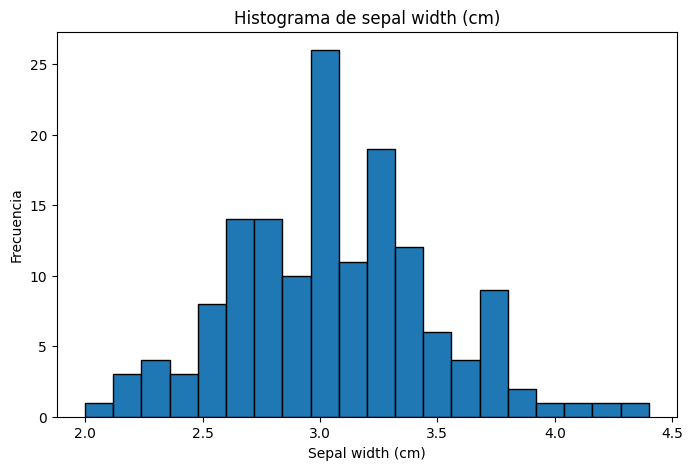

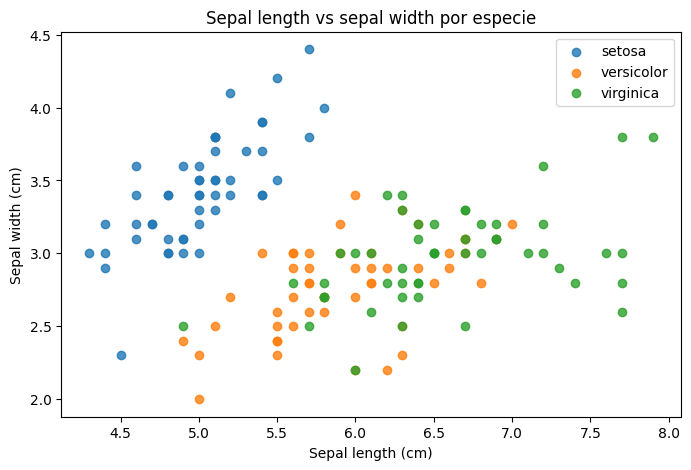

Cantidad de flores con petal length (cm) mayor que 6.0: 9
X_train_33: (100, 4)
X_test_33: (50, 4)
y_train_33: (100,)
y_test_33: (50,)
Ejercicio 7
Media del área del pétalo: 5.79
Ejercicio 8
Matriz de correlación:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  

Par con mayor correlación positiva: ('petal length (cm)', 'petal width (cm)')
Valor de correlación: 0.96
Esto significa que, cuando una de esas características aumenta, la otra tiende a aumentar también.
Ejerci

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [41]:
# Espacio de trabajo para los ejercicios

# Ejercicio 1:
sepal_length = iris_df['sepal length (cm)']

media = sepal_length.mean()
mediana = sepal_length.median()
desviacion_estandar = sepal_length.std()

print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación estándar: {desviacion_estandar:.2f}")

# Ejercicio 2:
virginica_df = iris_df[iris_df['species_name'] == 'virginica']
promedio_petal_width_virginica = virginica_df['petal width (cm)'].mean()

print(f"Promedio de petal width (cm) para virginica: {promedio_petal_width_virginica:.2f}")


# Ejercicio 3:
plt.figure(figsize=(8, 5))
plt.hist(iris_df['sepal width (cm)'], bins=20, edgecolor='black')
plt.title('Histograma de sepal width (cm)')
plt.xlabel('Sepal width (cm)')
plt.ylabel('Frecuencia')
plt.show()


# Ejercicio 4:
plt.figure(figsize=(8, 5))
colores_especies = {
    'setosa': 'tab:blue',
    'versicolor': 'tab:orange',
    'virginica': 'tab:green'
}

for species_name, group in iris_df.groupby('species_name'):
    plt.scatter(
        group['sepal length (cm)'],
        group['sepal width (cm)'],
        color=colores_especies[species_name],
        label=species_name,
        alpha=0.8
    )

plt.title('Sepal length vs sepal width por especie')
plt.xlabel('Sepal length (cm)')
plt.ylabel('Sepal width (cm)')
plt.legend()
plt.show()


# Ejercicio 5:
flores_petal_length_mayor_6 = iris_df[iris_df['petal length (cm)'] > 6.0]
cantidad_flores_petal_length_mayor_6 = len(flores_petal_length_mayor_6)

print(f"Cantidad de flores con petal length (cm) mayor que 6.0: {cantidad_flores_petal_length_mayor_6}")
flores_petal_length_mayor_6


# Ejercicio 6:
X_train_33, X_test_33, y_train_33, y_test_33 = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=100
)

print(f"X_train_33: {X_train_33.shape}")
print(f"X_test_33: {X_test_33.shape}")
print(f"y_train_33: {y_train_33.shape}")
print(f"y_test_33: {y_test_33.shape}")


# Ejercicio 7:
print('Ejercicio 7')
iris_df['petal_area'] = iris_df['petal length (cm)'] * iris_df['petal width (cm)']
media_petal_area = iris_df['petal_area'].mean()

print(f"Media del área del pétalo: {media_petal_area:.2f}")


# Ejercicio 8:
print('Ejercicio 8')

matriz_correlacion = X.corr()
print("Matriz de correlación:")
print(matriz_correlacion)

correlaciones_pares = matriz_correlacion.unstack()
correlaciones_pares = correlaciones_pares[correlaciones_pares < 1]
par_mayor_correlacion = correlaciones_pares.idxmax()
valor_mayor_correlacion = correlaciones_pares.max()

print(f"\nPar con mayor correlación positiva: {par_mayor_correlacion}")
print(f"Valor de correlación: {valor_mayor_correlacion:.2f}")
print("Esto significa que, cuando una de esas características aumenta, la otra tiende a aumentar también.")


# Ejercicio 9:
print('Ejercicio 9')

X_train_sin_stratify, X_test_sin_stratify, y_train_sin_stratify, y_test_sin_stratify = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Distribución en y_train sin stratify:")
print(y_train_sin_stratify.value_counts(normalize=True))

print("\nDistribución en y_test sin stratify:")
print(y_test_sin_stratify.value_counts(normalize=True))

print("\nCon stratify, la proporción de clases se mantiene más parecida entre entrenamiento y prueba.")
print("Esto es útil para evitar que alguna clase quede subrepresentada en alguno de los conjuntos.")


# Ejercicio 10:
from sklearn.datasets import load_wine

wine_raw = load_wine()
wine_df = pd.DataFrame(data=wine_raw.data, columns=wine_raw.feature_names)
wine_df['target'] = wine_raw.target
wine_df['target_name'] = wine_df['target'].map({i: name for i, name in enumerate(wine_raw.target_names)})

print("Primeras filas del dataset Wine:")
print(wine_df.head())

print("\nInformación general del dataset Wine:")
wine_df.info()

print("\nResumen estadístico del dataset Wine:")
wine_df.describe()
